# S&P 500 Historical Market Performance Analysis

This project analyzes nearly 100 years of S&P 500 market data using Python and Pandas to identify long-term trends, volatility patterns, and major market events.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(
    '/content/drive/MyDrive/Projects/Stock_Market_Analysis/sap500.xlsx'
)

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1927-12-30,17.660000,17.660000,17.660000,17.660000,0
1,1928-01-03,17.760000,17.760000,17.760000,17.760000,0
2,1928-01-04,17.719999,17.719999,17.719999,17.719999,0
3,1928-01-05,17.549999,17.549999,17.549999,17.549999,0
4,1928-01-06,17.660000,17.660000,17.660000,17.660000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24721 entries, 0 to 24720
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    24721 non-null  datetime64[ns]
 1   Open    24721 non-null  float64       
 2   High    24721 non-null  float64       
 3   Low     24721 non-null  float64       
 4   Close   24721 non-null  float64       
 5   Volume  24721 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.1 MB


In [6]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,24721,24721.000000,24721.000000,24721.000000,24721.000000,2.472100e+04
mean,1977-04-15 21:57:05.541038016,741.012726,745.259237,736.506863,741.182015,9.812877e+08
min,1927-12-30 00:00:00,4.400000,4.400000,4.400000,4.400000,0.000000e+00
25%,1952-09-26 00:00:00,24.980000,24.980000,24.980000,24.980000,1.610000e+06
50%,1977-05-18 00:00:00,103.709999,104.589996,102.879997,103.720001,2.257000e+07
75%,2001-11-06 00:00:00,1095.699951,1102.770020,1088.400024,1095.680054,1.203000e+09
max,2026-06-02 00:00:00,7595.399902,7620.899902,7582.990234,7609.779785,1.145623e+10
std,NaN,1279.281554,1286.017496,1272.093207,1279.593049,1.699967e+09


In [7]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24721 entries, 0 to 24720
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    24721 non-null  datetime64[ns]
 1   Open    24721 non-null  float64       
 2   High    24721 non-null  float64       
 3   Low     24721 non-null  float64       
 4   Close   24721 non-null  float64       
 5   Volume  24721 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.1 MB


In [11]:
df['Year'] = df['Date'].dt.year

In [12]:
df['Month'] = df['Date'].dt.month

In [13]:
df['Daily_Return'] = df['Close'].pct_change() * 100

In [14]:
annual_return = df.groupby('Year')['Daily_Return'].mean()

annual_return.head()

,Daily_Return
Year,
1927,NaN
1928,0.132949
1929,-0.023030
1930,-0.118062
1931,-0.218345


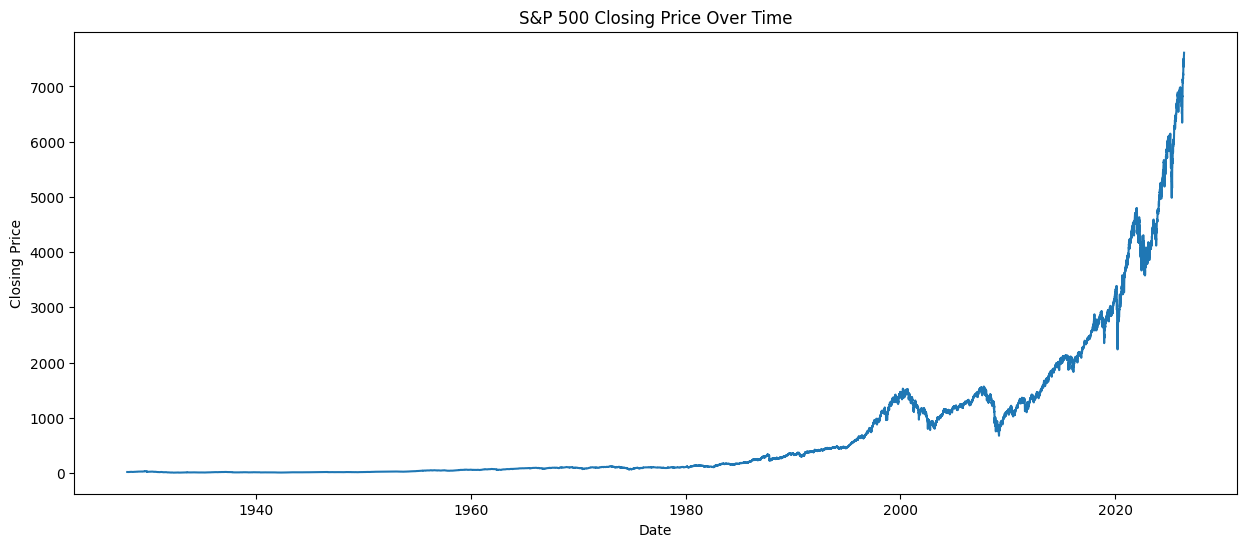

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Close'])

plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [16]:
df.to_csv('sp500_cleaned.csv', index=False)

## Highest and Lowest Closing Price

In [18]:
highest_close = df['Close'].max()

print("Highest Closing Price:", highest_close)

Highest Closing Price: 7609.77978515625


In [19]:
lowest_close = df['Close'].min()

print("Lowest Closing Price:", lowest_close)

Lowest Closing Price: 4.400000095367432


In [20]:
df[df['Close'] == df['Close'].max()]

,Date,Open,High,Low,Close,Volume,Year,Month,Daily_Return
24720,2026-06-02,7595.399902,7620.899902,7582.990234,7609.779785,5904410000,2026,6,0.129209


In [21]:
df[df['Close'] == df['Close'].min()]

,Date,Open,High,Low,Close,Volume,Year,Month,Daily_Return
1106,1932-06-01,4.4,4.4,4.4,4.4,0,1932,6,-1.565989


In [22]:
df[df['Close'] == df['Close'].min()]

,Date,Open,High,Low,Close,Volume,Year,Month,Daily_Return
1106,1932-06-01,4.4,4.4,4.4,4.4,0,1932,6,-1.565989


In [23]:
df[df['Volume'] == df['Volume'].max()]

,Date,Open,High,Low,Close,Volume,Year,Month,Daily_Return
20284,2008-10-10,902.309998,936.359985,839.799988,899.219971,11456230000,2008,10,-1.175929


## Best and Worst Years

In [24]:
annual_returns = df.groupby('Year')['Daily_Return'].mean()

In [25]:
annual_returns.idxmax()

np.int32(1933)

In [26]:
annual_returns.max()

0.19739214274165737

In [27]:
annual_returns.idxmin()

np.int32(1931)

In [28]:
annual_returns.min()

-0.2183451759075376

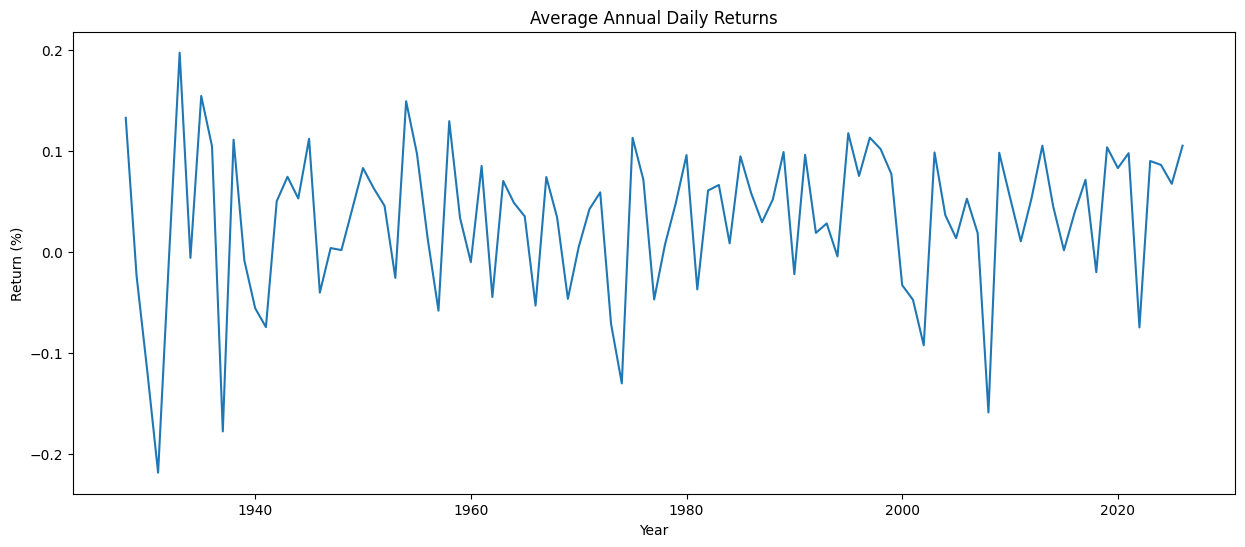

In [29]:
import matplotlib.pyplot as plt

annual_returns.plot(
    figsize=(15,6),
    title='Average Annual Daily Returns'
)

plt.ylabel('Return (%)')
plt.show()

## Moving Average Analysis

In [30]:
df['MA20'] = df['Close'].rolling(20).mean()

df['MA50'] = df['Close'].rolling(50).mean()

df['MA200'] = df['Close'].rolling(200).mean()

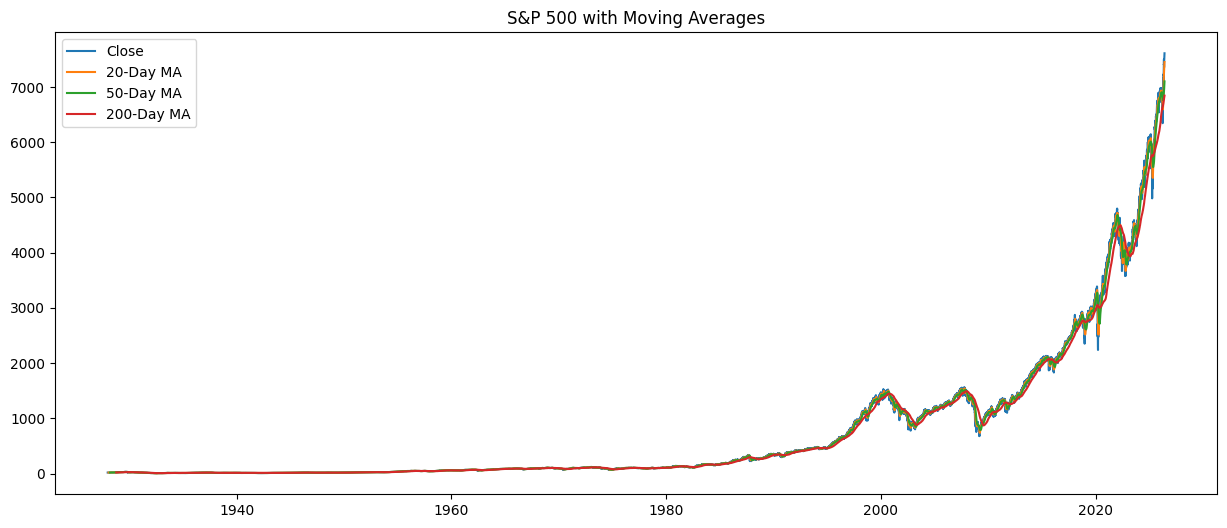

In [31]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Close'], label='Close')

plt.plot(df['Date'], df['MA20'], label='20-Day MA')

plt.plot(df['Date'], df['MA50'], label='50-Day MA')

plt.plot(df['Date'], df['MA200'], label='200-Day MA')

plt.legend()

plt.title('S&P 500 with Moving Averages')

plt.show()

## Volatility Analysis

In [32]:
df['Volatility'] = df['Daily_Return'].rolling(30).std()

In [33]:
df['Volatility'].max()

5.646934230806204

In [34]:
df.loc[df['Volatility'].idxmax()]

,472
Date,1929-11-19 00:00:00
Open,20.700001
High,20.700001
Low,20.700001
Close,20.700001
Volume,0
Year,1929
Month,11
Daily_Return,3.03634
MA20,22.37


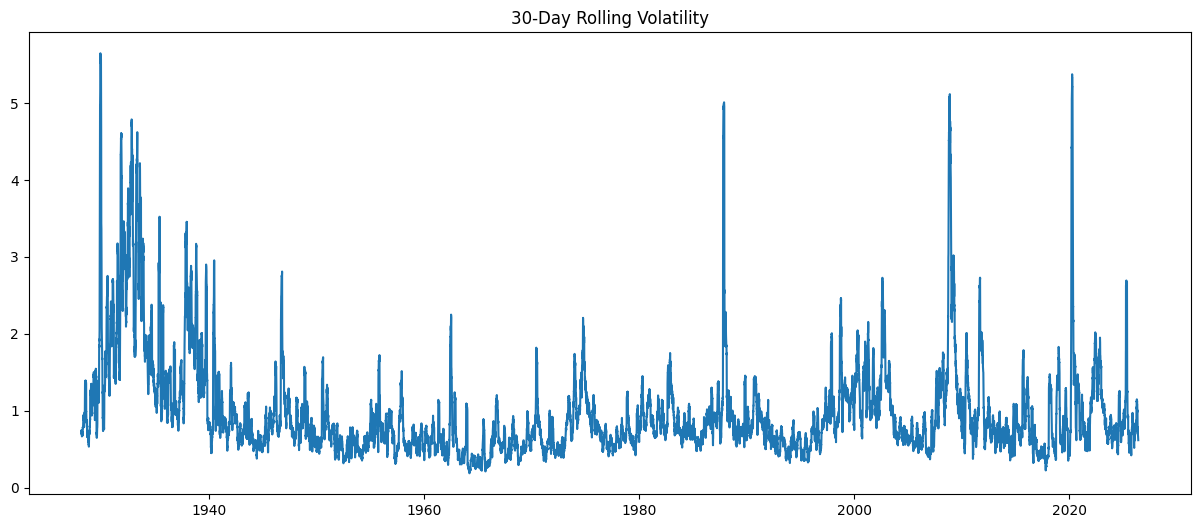

In [35]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Volatility'])

plt.title('30-Day Rolling Volatility')

plt.show()

# Market Crash Analysis
## 2008 Financial Crisis

In [41]:
crisis_2008 = df[
    (df['Date'] >= '2007-01-01') &
    (df['Date'] <= '2010-12-31')
]

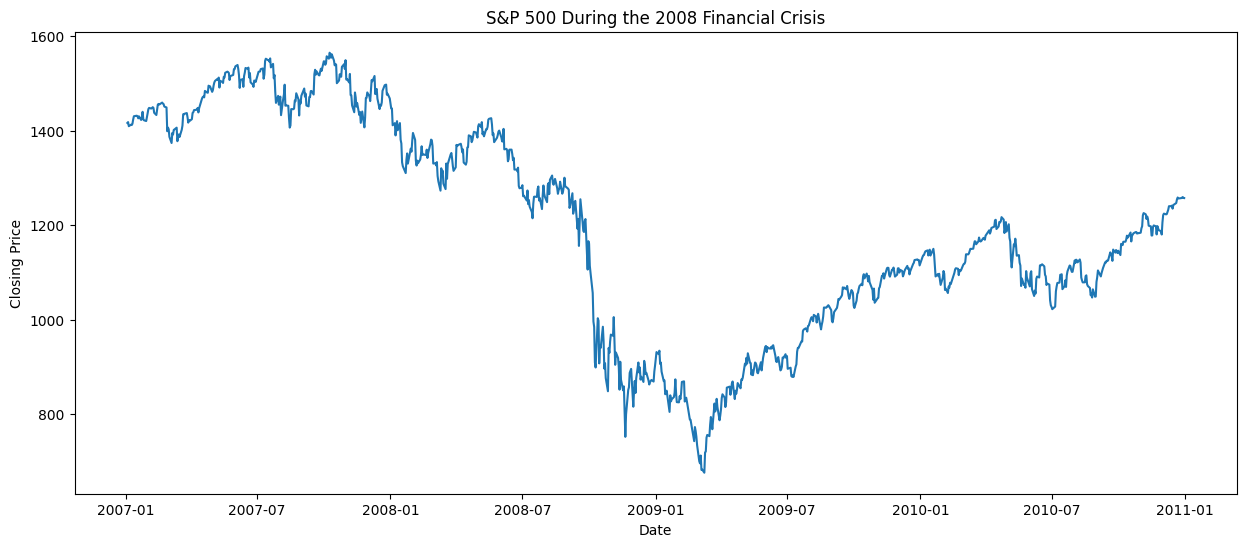

In [42]:
plt.figure(figsize=(15,6))

plt.plot(
    crisis_2008['Date'],
    crisis_2008['Close']
)

plt.title('S&P 500 During the 2008 Financial Crisis')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

## COVID-19 Market Crash

In [43]:
covid = df[
    (df['Date'] >= '2019-01-01') &
    (df['Date'] <= '2021-12-31')
]

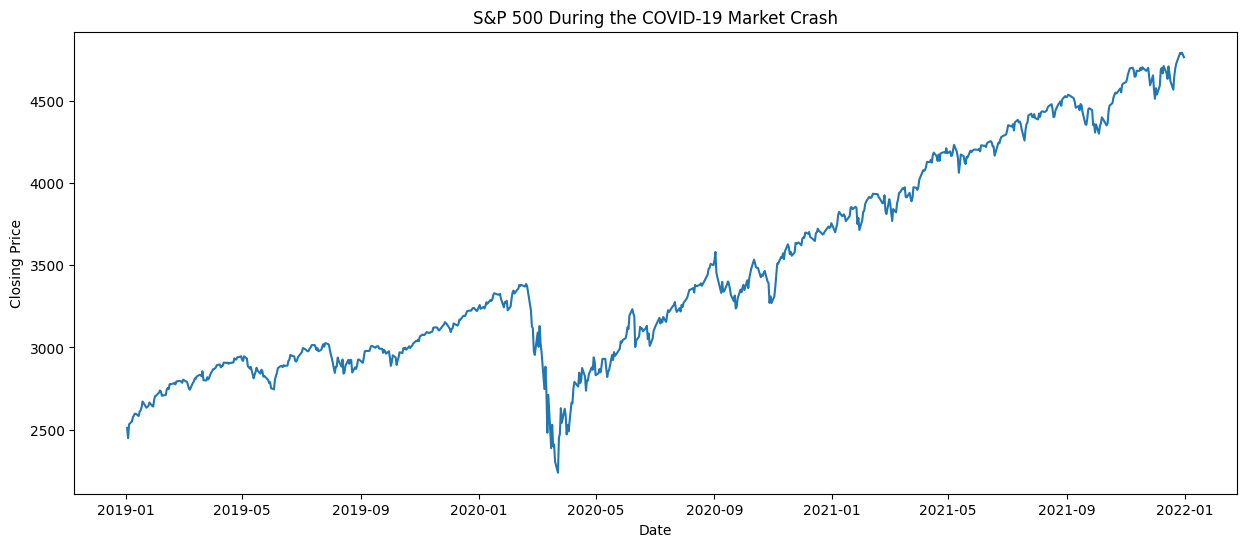

In [44]:
plt.figure(figsize=(15,6))

plt.plot(
    covid['Date'],
    covid['Close']
)

plt.title('S&P 500 During the COVID-19 Market Crash')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

# Conclusion
This analysis examined nearly 100 years of S&P 500 market data using Python, Pandas, and data visualization techniques to evaluate long-term market performance, volatility, and investor behavior. Through exploratory data analysis, feature engineering, moving average calculations, and rolling volatility measurements, key market trends and historical turning points were identified. The analysis also investigated major economic events, including the Great Depression, the 2008 Financial Crisis, and the COVID-19 market crash, to better understand how periods of uncertainty affect market performance.

The findings revealed that while financial markets can experience significant declines and extreme volatility during times of economic stress, the S&P 500 has demonstrated remarkable resilience over the long term. The strongest average annual performance occurred in 1933 during the recovery from the Great Depression, while the weakest performance occurred in 1931 during the height of the economic downturn. Trading volume peaked during the 2008 Financial Crisis, and the highest volatility levels were observed following the 1929 market crash. These results highlight the relationship between market uncertainty, investor behavior, and risk while demonstrating the value of historical analysis for understanding long-term market trends. For investors, analysts, and business decision-makers, this analysis provides valuable context for evaluating risk, interpreting market conditions, and understanding how markets have historically responded to major economic events.
